In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch as pt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
import HierarchBayesParcel.arrangements as ar
from IndividualParcellation.global_config import *
from OptimalBattery.plot import plot_correlations
from Functional_Fusion.util import get_volumes
import SUITPy.flatmap as flatmap

NameError: Could not find model_dir

In [ ]:
atlas,_= am.get_atlas(atlas_str='SUIT3')

In [ ]:
prob_parcel_dir = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/'
if not os.path.exists(prob_parcel_dir):
    prob_parcel_dir = '/cifs/diedrichsen/data/Cerebellum/Language/ProbabilisticParcellations/'
# load model pkl
with open(f'{prob_parcel_dir}/mdtb-s1_mdtb-s2_fusion_k4_SUIT3.pkl', 'rb') as f:
    full_model = pickle.load(f)

In [4]:
ar_model_logpi = full_model.arrange.logpi
# move to gpu
ar_model_logpi = ar_model_logpi.to(DEVICE)

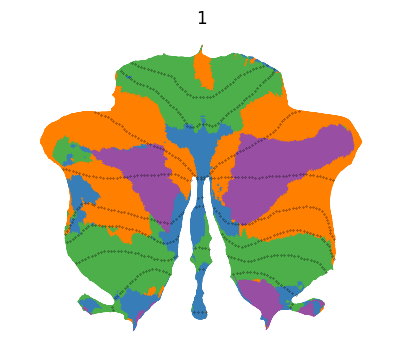

In [5]:
group = full_model.arrange.logpi
group_prob = pt.softmax(group,dim=0)
group_prob = group_prob.reshape(1,-1,group_prob.shape[-1])


group_vol = get_volumes(group_prob.cpu().numpy(),atlas_name='SUIT3')
flatmap.plot_multi_flat(group_vol,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,2),
                        bordersize = 0.5,
                        fig_size = (20,20))

In [6]:
# Make an arrangement model (from group prior)
ar_model = ar.build_arrangement_model(ar_model_logpi, prior_type='logpi', atlas=atlas,
                                        sym_type='asym')

In [7]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0


data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0

In [8]:
# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

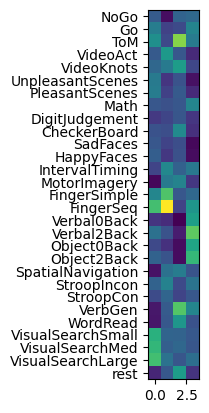

In [9]:
plt.imshow(mdtb_1_Vs)
cond_names = info_mdtb_1_run['cond_name'][:29]
# add condition names from the info file
plt.yticks(np.arange(len(cond_names)), cond_names)
plt.show()

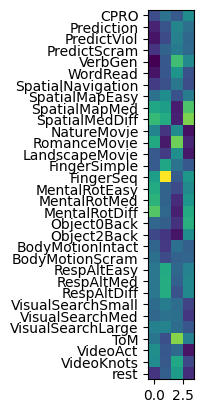

(24, 2, 6918)


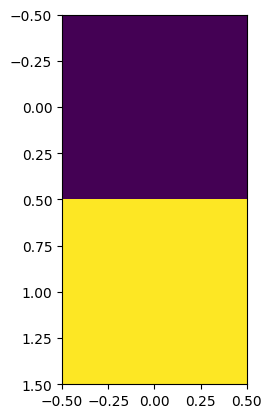

In [10]:
plt.imshow(mdtb_2_Vs)
cond_names = info_mdtb_2_all['cond_name'][:32]
# add condition names from the info file
plt.yticks(np.arange(len(cond_names)), cond_names)
plt.show()

vtest = mdtb_2_Vs[13:15,1]
vtest = vtest.reshape(-1,1)
plt.imshow(vtest)

tdata = data_mdtb_s2_all[:,13:15,:]
print(tdata.shape)

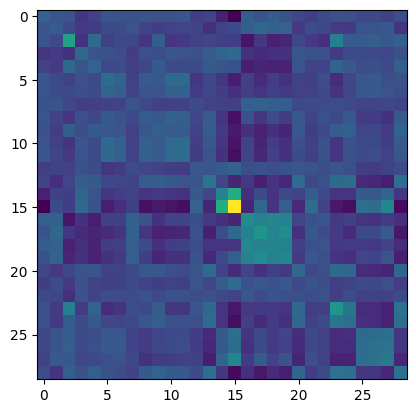

In [11]:
plt.imshow(GL_mdtb)

In [13]:
def evaluate_cos(D, ytrain,info, Vs,ytest_run, vtest,M_test):
    # Create a new column with combinations as tuples to make them hashable
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    
    # Get unique combinations
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    cos_HBP_dict = {}

    ytest_run = pt.tensor(ytest_run,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)

    U_list = []
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)

        V_subset = Vs[task_subset_indices, :]
        V_subset = V_subset - np.mean(V_subset, axis=0)
        V_subset = V_subset / np.linalg.norm(V_subset, axis=0)


        y_subset = ytrain[:, task_subset_indices, :]
        y_subset = y_subset - np.mean(y_subset, axis=0)
        y_subset = y_subset / np.linalg.norm(y_subset, axis=0)


        # leverage repeats for HBP
        HBP_data,HBP_cond_vec,HBP_part_vec = ut.make_dataset(ytrain,info,task_subset_indices,n_repeats=2)
        U_hat_HBP ,kappa = HBP_u(HBP_data, HBP_cond_vec, HBP_part_vec)
        U_hat_HBP_eval = U_hat_HBP[:,1,:]
        if U_hat_HBP_eval.ndim == 2:
            U_hat_HBP_eval = U_hat_HBP_eval.reshape(-1,1,U_hat_HBP_eval.shape[1])
        U_list.append(U_hat_HBP)
        U_hat_HBP_eval = [U_hat_HBP_eval]
        kappa = kappa.item()     
        
        # Compute cos_HBP
        cos_HBP = calc_test_error(M=M_test, tdata=ytest_run, U_hats=U_hat_HBP_eval, fit_emission='use_Uhats').mean()
        
        # Store the result in the dictionary
        cos_HBP_dict[comb_tuple] = cos_HBP
    
    # Map the computed cos_HBP values back to the DataFrame
    D['cos_HBP'] = D['combination_tuple'].map(cos_HBP_dict)
    
    return D, U_list

In [17]:
def evaluate_cos_projection(D, ytrain,info, Vs,ytest_run, vtest,M_test):
    # Create a new column with combinations as tuples to make them hashable
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    
    # Get unique combinations
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    cos_dict = {}

    ytest_run = pt.tensor(ytest_run,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)

    U_list = []
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)

        V_subset = Vs[task_subset_indices, :]
        V_subset = V_subset - np.mean(V_subset, axis=0)
        V_subset = V_subset / np.linalg.norm(V_subset, axis=0)


        y_subset = ytrain[:, task_subset_indices, :]
        y_subset = y_subset - np.mean(y_subset, axis=0)
        y_subset = y_subset / np.linalg.norm(y_subset, axis=0)


        # projection for each subject
        U_hats = []
        for i in range(y_subset.shape[0]):
            U_hat = V_subset.T @ y_subset[i,:,:]
            max_indices = np.argmax(U_hat, axis=0)
            U_hat = np.zeros_like(U_hat)
            U_hat[max_indices, np.arange(U_hat.shape[1])] = 1
            U_hats.append(U_hat)

        # stack the U_hats
        U_hats = np.stack(U_hats)
        U_hats = pt.tensor(U_hats,dtype=pt.float32)

        U_list.append(U_hats)
        U_hat_eval = U_hats[:,1,:]
        if U_hat_eval.ndim == 2:
            U_hat_eval = U_hat_eval.reshape(-1,1,U_hat_eval.shape[1])
        
        # Compute cos_HBP
        cos = coserr(ytest_run,vtest,U_hat_eval,adjusted=False)
        # Store the result in the dictionary
        cos_dict[comb_tuple] = cos.mean().item()
    
    # Map the computed cos_HBP values back to the DataFrame
    D['cos_projection'] = D['combination_tuple'].map(cos_dict)
    
    return D, U_list

In [15]:
cond_vec_test = np.tile(np.arange(1, 2 + 1), 1)
part_vec_test = np.repeat(np.arange(1, 1 + 1), 2)
data_test = tdata


x_matrix = indicator(cond_vec_test)


em_model = em.MixVMF(K=4, P=6918, X=x_matrix, part_vec=part_vec_test,
                    subject_specific_kappa=False, parcel_specific_kappa=False, 
                    subjects_equal_weight=True)

M_2 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
M_2.initialize([data_test])

M_2, ll,_,U_individual = M_2.fit_em(iter=200, tol=0.01,
                                fit_arrangement=False,
                                fit_emission= True,
                                first_evidence=False)    


In [23]:
offsets = [1e-10,1e-8,1e-6,1e-4,1e-2,1,1e2,1e4,1e6,1e8,1e10]
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',offs = offsets,n_iter=1000,n_tasks=8,seed=3)
D_mdtb , U_list= evaluate_cos_projection(D_mdtb, data_mdtb_s1_run,info_mdtb_1_run,VL_mdtb,tdata, vtest,M_2)


building0


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
C:\Users\barafat\AppData\Local\Temp\ipykernel_25736\406170013.py:30: RuntimeWarning: invalid value encountered in divide
  y_subset = y_subset / np.linalg.norm(y_subset, axis=0)


Processing combination: 0
Processing combination: 1
Processing combination: 2
Processing combination: 3
Processing combination: 4
Processing combination: 5
Processing combination: 6
Processing combination: 7
Processing combination: 8
Processing combination: 9
Processing combination: 10
Processing combination: 11
Processing combination: 12
Processing combination: 13
Processing combination: 14
Processing combination: 15
Processing combination: 16
Processing combination: 17
Processing combination: 18
Processing combination: 19
Processing combination: 20
Processing combination: 21
Processing combination: 22
Processing combination: 23
Processing combination: 24
Processing combination: 25
Processing combination: 26
Processing combination: 27
Processing combination: 28
Processing combination: 29
Processing combination: 30
Processing combination: 31
Processing combination: 32
Processing combination: 33
Processing combination: 34
Processing combination: 35
Processing combination: 36
Processing 

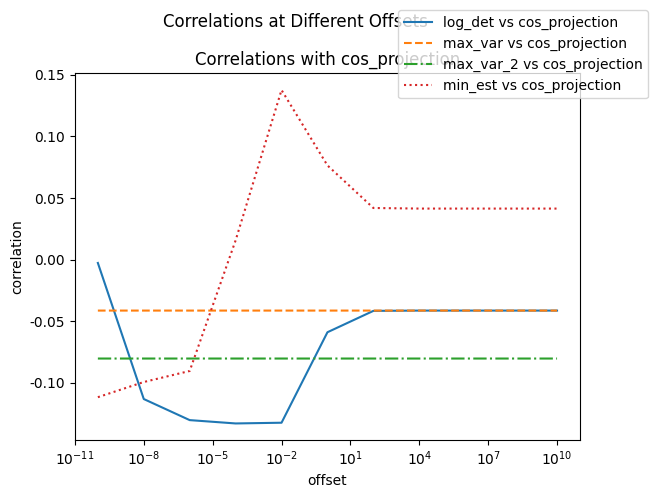

In [24]:
plot_correlations(D_mdtb, x_vars=['log_det','max_var','max_var_2','min_est'], y_vars=['cos_projection'])

In [37]:
# find the combination with the lowest cos_HBP , use one offset for the dataframe
D_offset = D_mdtb[D_mdtb['offset'] == 1e-2].reset_index(drop=True)
best_comb_index = D_offset['cos_projection'].idxmin()
worst_comb_index = D_offset['cos_projection'].idxmax()

print(best_comb_index)
print(worst_comb_index)

best_comb_us = U_list[best_comb_index]
worst_comb_us = U_list[worst_comb_index]

832
949


In [30]:
def evaluate_cos_single(combination, ytrain,info, Vs,ytest_run, vtest,M_test):
    ytest_run = pt.tensor(ytest_run,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)

    # Get the task subset indices and corresponding data
    task_subset_indices = list(combination)

    V_subset = Vs[task_subset_indices, :]
    V_subset = V_subset - np.mean(V_subset, axis=0)
    V_subset = V_subset / np.linalg.norm(V_subset, axis=0)


    y_subset = ytrain[:, task_subset_indices, :]
    y_subset = y_subset - np.mean(y_subset, axis=0)
    y_subset = y_subset / np.linalg.norm(y_subset, axis=0)


    # leverage repeats for HBP
    HBP_data,HBP_cond_vec,HBP_part_vec = ut.make_dataset(ytrain,info,task_subset_indices,n_repeats=2)
    U_hat_HBP ,kappa = HBP_u(HBP_data, HBP_cond_vec, HBP_part_vec)
    U_hat_HBP_eval = U_hat_HBP[:,1,:]
    if U_hat_HBP_eval.ndim == 2:
        U_hat_HBP_eval = U_hat_HBP_eval.reshape(-1,1,U_hat_HBP_eval.shape[1])
    U_hat_HBP_eval = [U_hat_HBP_eval]

    # Compute cos_HBP
    cos_HBP = calc_test_error(M=M_test, tdata=ytest_run, U_hats=U_hat_HBP_eval, fit_emission='use_Uhats').mean()


    
    return cos_HBP,U_hat_HBP

In [31]:
def evaluate_cos_single_projection(combination, ytrain,info, Vs,ytest_run, vtest,M_test):
    ytest_run = pt.tensor(ytest_run,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)

    # Get the task subset indices and corresponding data
    task_subset_indices = list(combination)

    V_subset = Vs[task_subset_indices, :]
    V_subset = V_subset - np.mean(V_subset, axis=0)
    V_subset = V_subset / np.linalg.norm(V_subset, axis=0)


    y_subset = ytrain[:, task_subset_indices, :]
    y_subset = y_subset - np.mean(y_subset, axis=0)
    y_subset = y_subset / np.linalg.norm(y_subset, axis=0)


    # leverage repeats for HBP
    U_hats = []
    for i in range(y_subset.shape[0]):
        U_hat = V_subset.T @ y_subset[i,:,:]
        max_indices = np.argmax(U_hat, axis=0)
        U_hat = np.zeros_like(U_hat)
        U_hat[max_indices, np.arange(U_hat.shape[1])] = 1
        U_hats.append(U_hat)

    # stack the U_hats
    U_hats = np.stack(U_hats)
    U_hats = pt.tensor(U_hats,dtype=pt.float32)

    U_list.append(U_hats)
    U_hat_eval = U_hats[:,1,:]
    if U_hat_eval.ndim == 2:
        U_hat_eval = U_hat_eval.reshape(-1,1,U_hat_eval.shape[1])
    
    # Compute cos_HBP
    cos = coserr(ytest_run,vtest,U_hat_eval,adjusted=False)
    cos = cos.mean().item()

    
    return cos,U_hats

In [34]:
combination = (3,4,3,4,3,4,3,4)
cos_trad,U_hat_trad = evaluate_cos_single_projection(combination, data_mdtb_s1_run,info_mdtb_1_run,VL_mdtb,tdata, vtest,M_2)


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
C:\Users\barafat\AppData\Local\Temp\ipykernel_25736\2340154014.py:15: RuntimeWarning: invalid value encountered in divide
  y_subset = y_subset / np.linalg.norm(y_subset, axis=0)


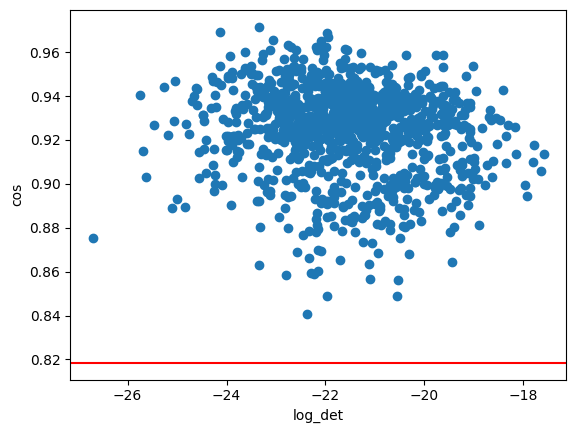

In [35]:
D_specific_offset = D_mdtb[D_mdtb['offset'] == 1e-2]
plt.scatter(D_specific_offset['log_det'], D_specific_offset['cos_projection'])
plt.axhline(y=cos_trad, color='r', linestyle='-')
plt.xlabel('log_det')
plt.ylabel('cos')
plt.show()

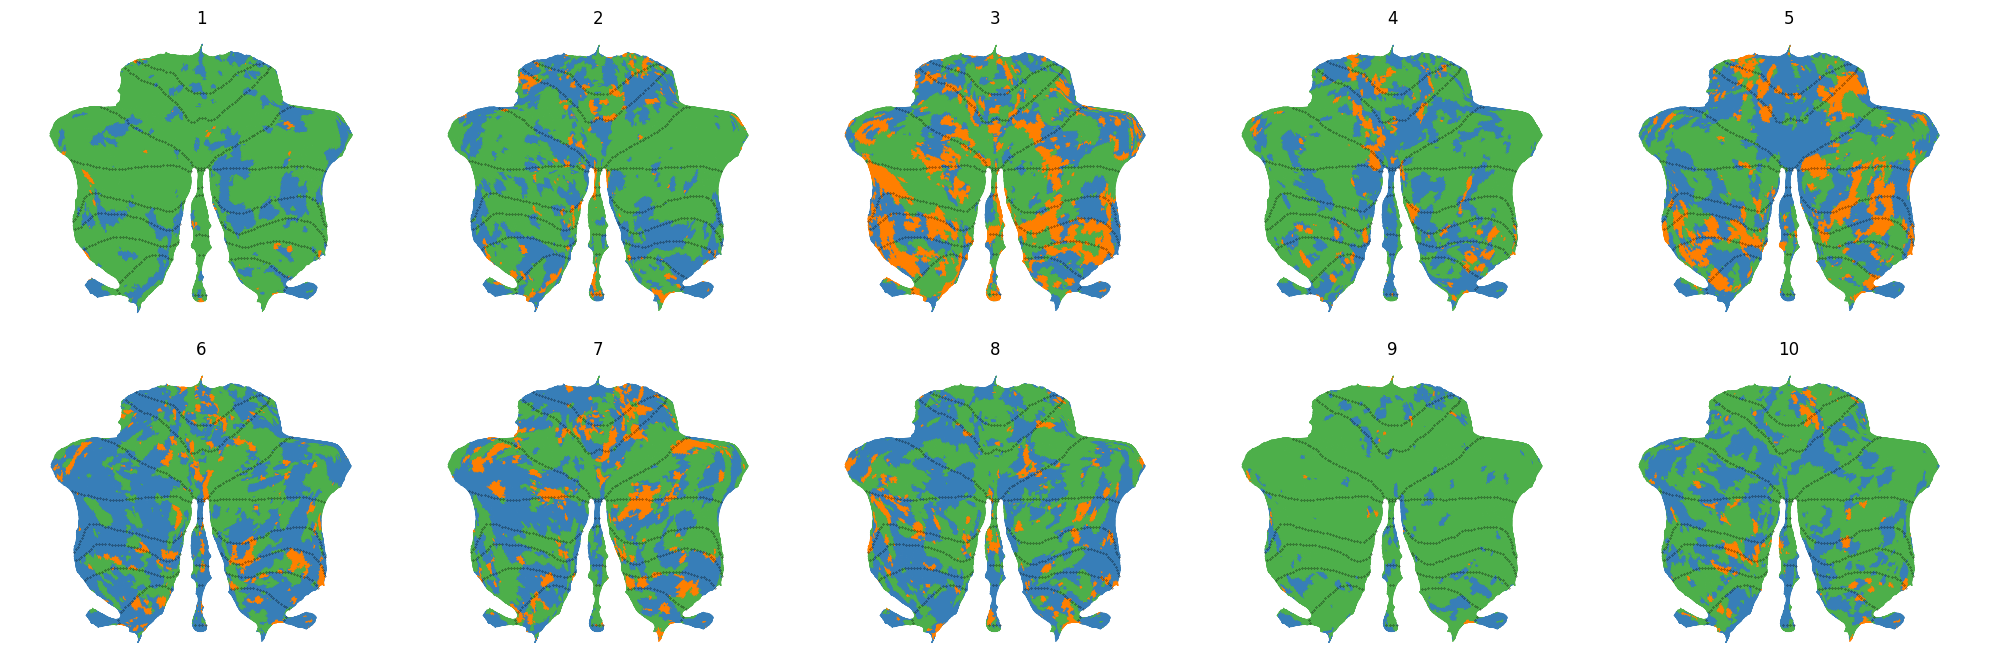

In [36]:
U_individual_volumes = get_volumes(U_hat_trad[:10].cpu().numpy(),atlas_name='SUIT3')
flatmap.plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,11),
                        bordersize = 0.5,
                        fig_size = (20,20))

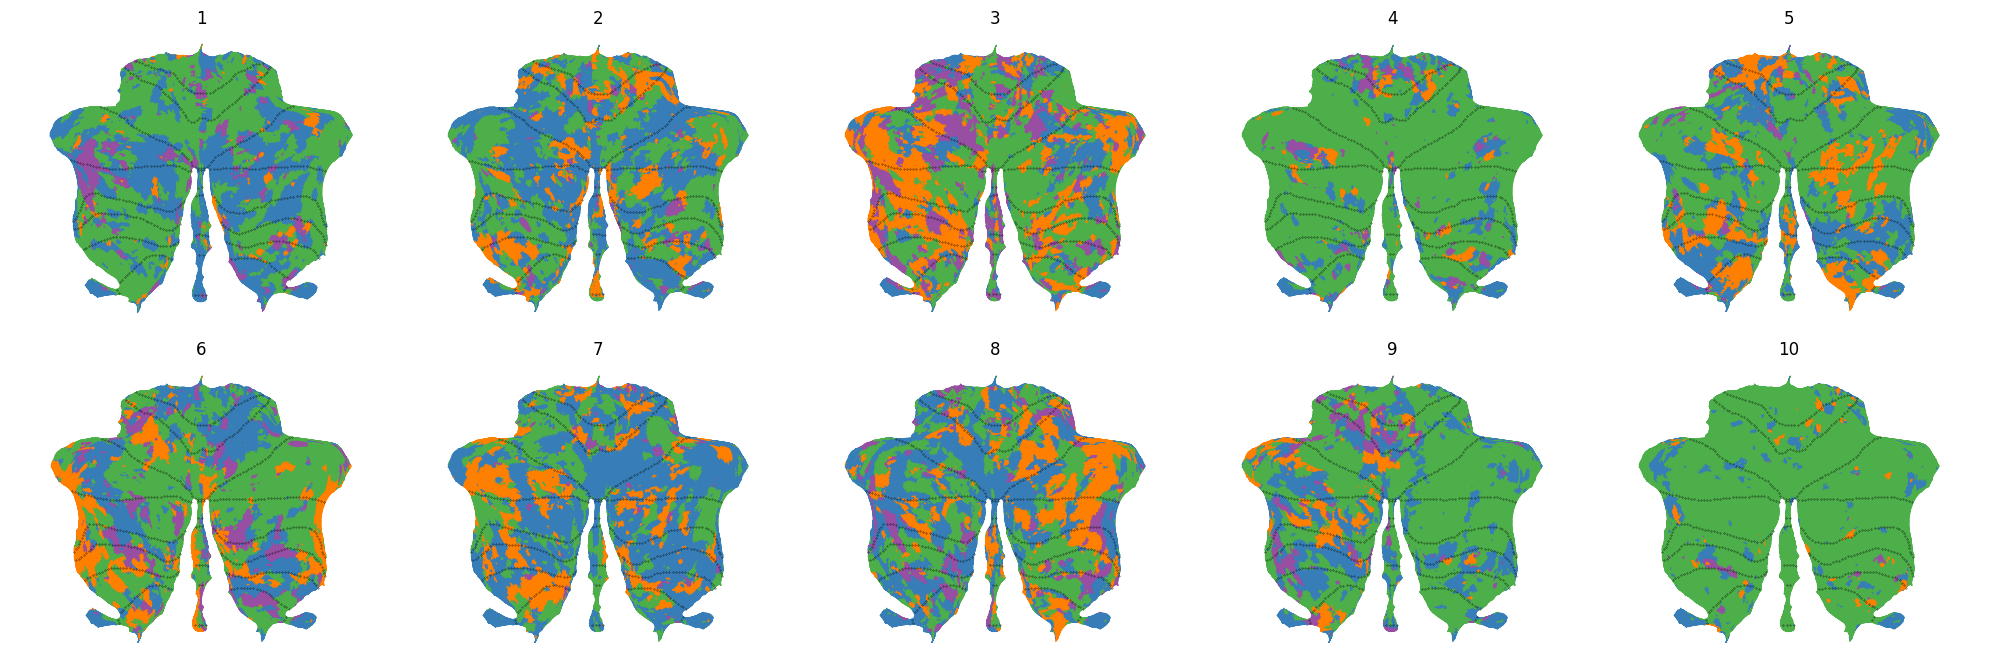

In [38]:
U_individual_volumes = get_volumes(best_comb_us[:10].cpu().numpy(),atlas_name='SUIT3')
flatmap.plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,11),
                        bordersize = 0.5,
                        fig_size = (20,20))

In [ ]:
U_individual_volumes = get_volumes(worst_comb_us[:10].cpu().numpy(),atlas_name='SUIT3')
flatmap.plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,11),
                        bordersize = 0.5,
                        fig_size = (20,20))